In [ ]:
"""
Статистическое обоснование attribution window.

Методы:
1. Распределение delta (post -> purchase)
2. Проверка временной структуры: KS + permutation/circular shift
3. Event study вокруг постов
4. Sensitivity analysis по attribution windows
5. Exploratory regression с лагами

Важно:
- post exposure пользователя не наблюдается;
- поэтому post -> purchase связь является модельной/агрегированной;
- attribution не интерпретируется как causal effect.

Вход:
    data/base.xlsx
    data/postupashki_posts.csv

Выход:
    outputs/*.csv
    outputs/plots/*.png
"""
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from pathlib import Path


np.random.seed(42)
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


# ============================================================
# ПУТИ
# ============================================================

BASE = Path(r'/content/')
# DATA = BASE / 'data'
OUT = BASE / 'outputs'
PLOTS = OUT / 'plots'

OUT.mkdir(exist_ok=True, parents=True)
PLOTS.mkdir(exist_ok=True, parents=True)


WINDOWS = [1, 3, 5, 7, 10, 14, 21, 30]
MARKETING_TYPES = ['discount', 'launch', 'urgency', 'offer']


# ============================================================
# 1. ЗАГРУЗКА И ОЧИСТКА
# ============================================================

def load_sales():
    """Загрузка покупок."""
    df = pd.read_excel('base.xlsx')
    df.columns = ['student_id', 'amount', 'course', 'timestamp']
    df['amount'] = (
        df['amount']
        .astype(str)
        .str.replace('\xa0', '', regex=False)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )
    df['timestamp'] = pd.to_datetime(
        df['timestamp'],
        format='%d.%m.%Y %H:%M:%S'
    )
    df['date'] = df['timestamp'].dt.normalize()

    return df


def load_posts():
    """Загрузка Telegram-постов."""
    df = pd.read_csv('postupashki_posts.csv')
    df['date'] = pd.to_datetime(df['date']).dt.normalize()
    df = df[df['type'].isin(MARKETING_TYPES)].copy()

    return df


# ============================================================
# 2. ПРЕОБРАЗОВАНИЕ ПОКУПОК В ORDERS
# ============================================================

def make_orders(sales):
    """
    Одна покупка может состоять из нескольких строк:
    один student_id + один timestamp.

    Поэтому attribution выполняем на уровне order.
    """
    orders = (
        sales
        .groupby(['student_id', 'timestamp', 'date'], as_index=False)
        .agg(
            order_amount=('amount', 'sum'),
            courses=('course', lambda x: ' | '.join(x.astype(str)))
        )
    )
    orders['order_id'] = np.arange(1, len(orders) + 1)

    return orders


# ============================================================
# 3. ПОСТЫ: УНИКАЛЬНЫЕ ДАТЫ
# ============================================================

def get_post_dates(posts):
    """Даты публикаций без дубликатов."""

    return (
        pd.Series(posts['date'].dropna().unique())
        .sort_values()
        .reset_index(drop=True)
    )


# ============================================================
# 4. БЛИЖАЙШИЙ ПРЕДЫДУЩИЙ ПОСТ
# ============================================================

def nearest_previous_post_dates(dates, post_dates):
    """
    Для каждой даты покупки ищет ближайший предыдущий
    день с маркетинговым постом.
    """
    post_dates = pd.DatetimeIndex(post_dates)
    result = []

    for date in dates:
        idx = post_dates.searchsorted(date, side='left')

        if idx == 0:
            result.append(pd.NaT)
        else:
            result.append(post_dates[idx - 1])

    return pd.Series(result, index=dates.index)


# ============================================================
# 5. МЕТОД 1: РАСПРЕДЕЛЕНИЕ DELTA
# ============================================================

def delta_distribution(orders, posts):
    """
    Для каждой покупки:
        delta = purchase_date - nearest_previous_post_date

    Это НЕ attribution window.
    Это предварительный анализ временной близости.
    """
    orders = orders.copy()
    post_dates = get_post_dates(posts)
    orders['prev_post_date'] = nearest_previous_post_dates(
        orders['date'],
        post_dates
    )
    orders['delta_days'] = (orders['date'] - orders['prev_post_date']).dt.days
    delta = (orders['delta_days'].dropna().astype(int))
    result = {
        'count': len(delta),
        'mean': delta.mean(),
        'median': delta.median(),
        'p75': delta.quantile(0.75),
        'p80': delta.quantile(0.80),
        'p90': delta.quantile(0.90),
        'p95': delta.quantile(0.95),
        'max': delta.max(),
    }
    print('\n' + '=' * 60)
    print('МЕТОД 1: РАСПРЕДЕЛЕНИЕ DELTA')
    print('=' * 60)

    for key, value in result.items():
        print(f'{key:10s}: {value:.2f}')
    print()

    for w in [1, 3, 5, 7, 10, 14]:
        print(
            f'P(delta <= {w:2d}) = '
            f'{(delta <= w).mean():.1%}'
        )

    # CSV
    orders[
        [
            'order_id',
            'student_id',
            'date',
            'order_amount',
            'prev_post_date',
            'delta_days'
        ]
    ].to_csv(OUT / 'delta_distribution.csv', index=False)

    # график
    fig, ax = plt.subplots()
    ax.hist(
        delta,
        bins=min(30, max(10, delta.max() + 1)),
        edgecolor='black',
        alpha=0.7
    )
    ax.axvline(
        delta.median(),
        linestyle='--',
        label=f'median = {delta.median():.0f}'
    )
    ax.axvline(3, linestyle='--', label='3 days')
    ax.set_xlabel('Дней от ближайшего предыдущего поста до покупки')
    ax.set_ylabel('Количество покупок')
    ax.set_title('Распределение временной близости покупки к постам')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS / 'delta_hist.png', dpi=150)
    plt.show()

    return orders, delta, result


# ============================================================
# 6. МЕТОД 2: NULL MODEL ДЛЯ KS
# ============================================================

def calculate_delta(dates, post_dates):
    """
    Для каждой даты покупки считает расстояние
    до ближайшего предыдущего поста.
    """
    post_dates = pd.DatetimeIndex(post_dates)
    deltas = []

    for date in dates:
        idx = post_dates.searchsorted(date, side='left')

        if idx == 0:
            continue
        prev_post = post_dates[idx - 1]
        delta = (date - prev_post).days
        deltas.append(delta)

    return np.array(deltas)


def circular_shift_dates(dates, shift_days):
    """
    Circular shift.

    Сохраняет форму временного ряда покупок,
    но разрушает синхронизацию с постами.
    """
    dates = pd.Series(pd.to_datetime(dates))
    start = dates.min()
    end = dates.max()
    period = (end - start).days + 1
    shifted = start + (
        (dates - start).dt.days + shift_days
    ) % period * pd.Timedelta(days=1)

    return shifted


def ks_null_test(orders, posts, n_permutations=5000, seed=42):
    """
    Проверка:

    H0:
        наблюдаемая временная близость покупок к постам
        соответствует независимой null-модели.

    H1:
        наблюдаемая структура отличается от null.

    Используется KS-statistic + circular-shift permutation test.
    """
    rng = np.random.default_rng(seed)
    post_dates = get_post_dates(posts)
    real_dates = orders['date']
    real_delta = calculate_delta(real_dates, post_dates)

    # --------------------------------------------------------
    # Простой baseline: случайные даты
    # --------------------------------------------------------

    date_range = pd.date_range(real_dates.min(), real_dates.max(), freq='D')
    random_dates = pd.Series(
        rng.choice(date_range, size=len(real_dates), replace=True)
    )
    random_delta = calculate_delta(random_dates, post_dates)
    ks_random = stats.ks_2samp(real_delta, random_delta)

    # --------------------------------------------------------
    # Circular shift permutation
    # --------------------------------------------------------

    observed_ks = ks_random.statistic
    null_ks = []
    period = (real_dates.max() - real_dates.min()).days + 1

    for _ in range(n_permutations):
        shift = rng.integers(1, period)
        shifted_dates = circular_shift_dates(real_dates, shift)
        shifted_delta = calculate_delta(shifted_dates, post_dates)

        if len(shifted_delta) == 0:
            continue
        ks = stats.ks_2samp(real_delta, shifted_delta).statistic
        null_ks.append(ks)

    null_ks = np.array(null_ks)
    permutation_p = (1 + np.sum(null_ks >= observed_ks)) / (len(null_ks) + 1)

    print('\n' + '=' * 60)
    print('МЕТОД 2: KS / NULL MODEL')
    print('=' * 60)
    print(
        f'Real delta:   '
        f'mean={real_delta.mean():.2f}, '
        f'median={np.median(real_delta):.0f}'
    )
    print(
        f'Random delta: '
        f'mean={random_delta.mean():.2f}, '
        f'median={np.median(random_delta):.0f}'
    )
    print(
        f'\nSimple random-date KS: '
        f'D={ks_random.statistic:.4f}, '
        f'p={ks_random.pvalue:.4f}'
    )
    print(
        f'Circular-shift permutation: '
        f'D={observed_ks:.4f}, '
        f'p={permutation_p:.4f}'
    )

    if permutation_p < 0.05:
        conclusion = (
            'наблюдаемая временная структура '
            'отличается от null-модели'
        )
    else:
        conclusion = (
            'отличие от null-модели '
            'статистически не обнаружено'
        )
    print(f'\nВывод: {conclusion}')

    # --------------------------------------------------------
    # График null distribution
    # --------------------------------------------------------

    fig, ax = plt.subplots()
    ax.hist(null_ks, bins=40, edgecolor='black', alpha=0.7)
    ax.axvline(
        observed_ks,
        linestyle='--',
        linewidth=2,
        label=f'observed D = {observed_ks:.3f}'
    )
    ax.set_xlabel('KS statistic D')
    ax.set_ylabel('Количество permutation samples')
    ax.set_title('Null distribution KS-statistic')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS / 'ks_null_distribution.png', dpi=150)
    plt.show()

    result = {
        'ks_statistic': observed_ks,
        'permutation_pvalue': permutation_p,
        'random_date_ks': ks_random.statistic,
        'random_date_pvalue': ks_random.pvalue,
        'real_mean_delta': real_delta.mean(),
        'real_median_delta': np.median(real_delta),
        'random_mean_delta': random_delta.mean(),
        'random_median_delta': np.median(random_delta),
        'n_permutations': len(null_ks),
    }
    pd.DataFrame([result]).to_csv(OUT / 'ks_test.csv', index=False)

    return result


# ============================================================
# 7. МЕТОД 3: EVENT STUDY
# ============================================================

def event_study(orders, posts, event_type, window=14):
    """
    Revenue вокруг постов.

    Для каждого события:
        offset = -window ... +window

    Дополнительно считаем normalized revenue:
        revenue / pre-event baseline
    """
    daily = (
        orders
        .groupby('date')
        .agg(
            revenue=('order_amount', 'sum'),
            orders=('order_id', 'count')
        )
    )
    events = (
        posts.loc[posts['type'] == event_type, 'date']
        .drop_duplicates()
        .sort_values()
    )

    if len(events) == 0:
        return None
    rows = []

    for event_date in events:
        # baseline = средняя revenue за -3:-1
        pre_days = [event_date + pd.Timedelta(days=i) for i in range(-3, 0)]
        pre_revenue = [
            daily.loc[d, 'revenue'] for d in pre_days if d in daily.index
        ]

        if len(pre_revenue) == 0:
            baseline = np.nan
        else:
            baseline = np.mean(pre_revenue)

        for offset in range(-window, window + 1):
            day = (event_date + pd.Timedelta(days=offset))

            if day in daily.index:
                revenue = daily.loc[day, 'revenue']
                orders_count = daily.loc[day, 'orders']
            else:
                revenue = np.nan
                orders_count = np.nan
            rows.append({
                'event_date': event_date,
                'offset': offset,
                'revenue': revenue,
                'orders': orders_count,
                'baseline': baseline,
                'relative_revenue': (
                    revenue / baseline
                    if pd.notna(baseline) and baseline != 0
                    else np.nan
                )
            })
    df = pd.DataFrame(rows)
    agg = (
        df
        .groupby('offset')
        .agg(
            mean_revenue=('revenue', 'mean'),
            median_revenue=('revenue', 'median'),
            mean_relative=('relative_revenue', 'mean'),
            count=('revenue', 'count')
        )
        .reset_index()
    )
    agg.to_csv(OUT / f'event_study_{event_type}.csv', index=False)

    return agg


def plot_event_study(all_es):
    """График event study."""
    fig, ax = plt.subplots()

    for event_type, df in all_es.items():
        if df is None:
            continue
        ax.plot(df['offset'], df['mean_relative'], marker='o', label=event_type)
    ax.axvline(0, linestyle='--', alpha=0.5)
    ax.axhline(1, linestyle=':', alpha=0.7)
    ax.set_xlabel('Дней от публикации')
    ax.set_ylabel('Revenue / pre-event baseline')
    ax.set_title('Event study: относительный revenue вокруг постов')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS / 'event_study.png', dpi=150)
    plt.show()


# ============================================================
# 8. CANDIDATE TOUCHES
# ============================================================

def generate_touches(orders, posts, window):
    """
    Строит потенциальные касания:

    post_time <= purchase_time
    post_time >= purchase_time - window

    Это candidate touches, а не наблюдаемые exposures.
    """
    rows = []
    posts_sorted = posts.sort_values('date')

    for _, order in orders.iterrows():
        min_date = (order['date'] - pd.Timedelta(days=window))
        candidates = posts_sorted[
            (posts_sorted['date'] >= min_date) &
            (posts_sorted['date'] < order['date'])
        ]

        for _, post in candidates.iterrows():
            rows.append({
                'order_id': order['order_id'],
                'student_id': order['student_id'],
                'order_date': order['date'],
                'order_amount': order['order_amount'],
                'post_id': post['id'],
                'post_date': post['date'],
                'post_type': post['type'],
                'post_channel': post['channel'],
                'delta_days': (order['date'] - post['date']).days
            })

    return pd.DataFrame(rows)


# ============================================================
# 9. ATTRIBUTION MODELS
# ============================================================

def attribution_weights(deltas, model='time_decay', half_life=3.0):
    """Вес каждого candidate touch."""
    n = len(deltas)

    if n == 0:
        return np.array([])
    if model == 'first':
        weights = np.zeros(n)
        weights[0] = 1
    elif model == 'last':
        weights = np.zeros(n)
        weights[-1] = 1
    elif model == 'linear':
        weights = np.ones(n) / n
    elif model == 'position':
        if n == 1:
            weights = np.array([1.0])
        elif n == 2:
            weights = np.array([0.5, 0.5])
        else:
            weights = np.ones(n) * (0.2 / (n - 2))
            weights[0] = 0.4
            weights[-1] = 0.4
    elif model == 'time_decay':
        raw = 2 ** (-np.array(deltas) / half_life)
        weights = raw / raw.sum()
    else:
        raise ValueError(f'Unknown model: {model}')

    return weights


def attribute(touches, model='time_decay', half_life=3.0):
    """Attribution candidate touches."""
    if len(touches) == 0:
        return pd.DataFrame()
    result = []

    for order_id, group in touches.groupby('order_id'):
        group = (group.sort_values('post_date').reset_index(drop=True))
        amount = group['order_amount'].iloc[0]
        weights = attribution_weights(
            group['delta_days'].values,
            model=model,
            half_life=half_life
        )

        for i, row in group.iterrows():
            result.append({
                'order_id': order_id,
                'student_id': row['student_id'],
                'order_date': row['order_date'],
                'post_id': row['post_id'],
                'post_date': row['post_date'],
                'post_type': row['post_type'],
                'post_channel': row['post_channel'],
                'delta_days': row['delta_days'],
                'weight': weights[i],
                'attributed_revenue': (amount * weights[i]),
                'model': model
            })

    return pd.DataFrame(result)


# ============================================================
# 10. ATTRIBUTION SANITY CHECK
# ============================================================

def attribution_sanity_check(touches, attr):
    """
    Проверяет:

        sum(attributed revenue)
        =
        order revenue

    для каждого attributed order.
    """
    if len(attr) == 0:
        return None
    original = (touches.groupby('order_id')['order_amount'].first())
    attributed = (attr.groupby('order_id')['attributed_revenue'].sum())
    check = pd.concat([original, attributed], axis=1)
    check.columns = ['order_amount', 'attributed_revenue']
    check['difference'] = (check['order_amount'] - check['attributed_revenue'])
    max_error = check['difference'].abs().max()

    return check


# ============================================================
# 11. МЕТОД 4: SENSITIVITY ANALYSIS
# ============================================================

def sensitivity_analysis(orders, posts):
    """
    Проверяем attribution при разных окнах.

    Дополнительно:
    - coverage
    - median candidate touches
    - P90 candidate touches
    """
    models = ['first', 'last', 'linear', 'position', 'time_decay']
    rows = []

    for window in WINDOWS:
        touches = generate_touches(orders, posts, window)

        # coverage
        orders_with_touch = (
            touches['order_id']
            .nunique()
            if len(touches)
            else 0
        )
        coverage = (orders_with_touch / len(orders))

        if len(touches) == 0:
            continue
        touch_counts = (touches.groupby('order_id').size())

        for model in models:
            attr = attribute(touches, model=model)
            sanity = attribution_sanity_check(touches, attr)
            by_type = (
                attr.groupby('post_type')['attributed_revenue'].sum()
            )
            by_channel = (
                attr.groupby('post_channel')['attributed_revenue'].sum()
            )
            total = (by_type.sum())

            for post_type, revenue in (by_type.items()):
                rows.append({
                    'window': window,
                    'model': model,
                    'post_type': post_type,
                    'attributed_revenue': revenue,
                    'share': (revenue / total if total > 0 else 0),
                    'coverage': coverage,
                    'median_candidate_touches': (touch_counts.median()),
                    'p90_candidate_touches': (touch_counts.quantile(0.90))
                })

            for channel, revenue in by_channel.items():
                rows.append({
                    'window': window,
                    'model': model,
                    'post_type': f'channel::{channel}',
                    'attributed_revenue': revenue,
                    'share': revenue / total if total > 0 else 0,
                    'coverage': coverage,
                    'median_candidate_touches': touch_counts.median(),
                    'p90_candidate_touches': touch_counts.quantile(0.90)
                })
    df = pd.DataFrame(rows)
    df.to_csv(OUT / 'sensitivity_analysis.csv', index=False)

    # --------------------------------------------------------
    # Coverage
    # --------------------------------------------------------

    coverage = (
        df[
            [
                'window',
                'coverage',
                'median_candidate_touches',
                'p90_candidate_touches'
            ]
        ]
        .drop_duplicates()
        .sort_values('window')
    )
    coverage.to_csv(OUT / 'window_coverage.csv',index=False)

    print('\n' + '=' * 60)
    print('МЕТОД 4: SENSITIVITY ANALYSIS')
    print('=' * 60)
    print('\nCoverage и количество candidate touches:')
    print(
        coverage.to_string(
            index=False,
            formatters={
                'coverage': '{:.1%}'.format,
                'median_candidate_touches': '{:.1f}'.format,
                'p90_candidate_touches': '{:.1f}'.format
            }
        )
    )

    # --------------------------------------------------------
    # График attribution shares
    # --------------------------------------------------------

    time_decay = df[df['model'] == 'time_decay']
    fig, ax = plt.subplots()

    for post_type in (time_decay['post_type'].unique()):
        sub = time_decay[time_decay['post_type'] == post_type]
        ax.plot(sub['window'], sub['share'], marker='o', label=post_type)
    ax.axvline(2, linestyle='--', alpha=0.5, label='2 дня')
    ax.set_xlabel('Attribution window, дней')
    ax.set_ylabel('Доля attributed revenue')
    ax.set_title('Sensitivity attribution: time decay')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS / 'sensitivity_time_decay.png', dpi=150)
    plt.show()

    # --------------------------------------------------------
    # График candidate touches
    # --------------------------------------------------------

    fig, ax = plt.subplots()
    ax.plot(
        coverage['window'],
        coverage['median_candidate_touches'],
        marker='o',
        label='median'
    )
    ax.plot(
        coverage['window'],
        coverage['p90_candidate_touches'],
        marker='o',
        label='P90'
    )
    ax.set_xlabel('Attribution window, дней')
    ax.set_ylabel('Количество candidate touches')
    ax.set_title('Рост количества потенциальных касаний')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS / 'candidate_touches.png', dpi=150)
    plt.show()

    return df, coverage


# ============================================================
# 12. МЕТОД 5: EXPLORATORY REGRESSION
# ============================================================

def regression_lags(orders, posts):
    """
    Exploratory OLS.

    Не используется как causal proof.
    """
    daily = (
        orders
        .groupby('date')
        .agg(
            revenue=('order_amount', 'sum'),
            orders=('order_id', 'count')
        )
        .reset_index()
    )

    # создаём индикаторы наличия поста каждого типа
    for post_type in MARKETING_TYPES:
        dates = set(posts.loc[posts['type'] == post_type, 'date'])

        for lag in [0, 1, 3, 7, 14]:
            col = (f'{post_type}_lag{lag}')
            daily[col] = daily['date'].apply(
                lambda d:
                int(d - pd.Timedelta(days=lag) in dates)
            )

    # day of week
    daily['dow'] = (daily['date'].dt.dayofweek)
    feature_cols = [c for c in daily.columns if '_lag' in c]
    X = daily[feature_cols + ['dow']]
    X = pd.get_dummies(X, columns=['dow'], drop_first=True, dtype=float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X)
    y = daily['revenue']
    model = sm.OLS(y, X).fit()

    coefs = pd.DataFrame({
        'feature': model.params.index,
        'coef': model.params.values,
        'pvalue': model.pvalues.values
    })
    coefs = coefs[coefs['feature'] != 'const'].copy()
    coefs['significant_05'] = (coefs['pvalue'] < 0.05)
    coefs.to_csv(OUT / 'regression_lags.csv', index=False)

    print('\n' + '=' * 60)
    print('МЕТОД 5: EXPLORATORY REGRESSION')
    print('=' * 60)
    print(coefs.sort_values('pvalue').to_string(index=False))
    print(f'\nR² = {model.rsquared:.3f}')
    print(f'N = {len(daily)} days')
    print(
        '\nВАЖНО: регрессия используется только '
        'как exploratory analysis.'
    )

    return model, coefs


# ============================================================
# 13. АВТОМАТИЧЕСКАЯ СВОДКА ПО ОКНАМ
# ============================================================

def window_summary(delta_result, sensitivity, coverage, ks_result):
    """
    Формирует компактную таблицу для презентации.
    """
    summary = coverage.copy()
    summary['p80_delta'] = (delta_result['p80'])
    summary['ks_pvalue'] = (ks_result['permutation_pvalue'])
    summary.to_csv(OUT / 'window_summary.csv', index=False)
    print('\n' + '=' * 60)
    print('СВОДКА')
    print('=' * 60)
    print(
        f'P80 delta = '
        f'{delta_result["p80"]:.1f} дней'
    )
    print(
        f'KS permutation p-value = '
        f'{ks_result["permutation_pvalue"]:.4f}'
    )
    print('\nWindows:')
    print(
        summary.to_string(
            index=False,
            formatters={'coverage': '{:.1%}'.format}
        )
    )

    return summary

In [ ]:
# Графики
def plot_delta_by_post_type(sales, posts):
    post_dates = posts[['date', 'type']].drop_duplicates()
    rows = []

    for _, sale in sales.iterrows():
        prev = post_dates[post_dates['date'] < sale['date']]
        if len(prev) == 0:
            continue
        nearest = prev.loc[prev['date'].idxmax()]
        rows.append({
            'delta_days': (sale['date'] - nearest['date']).days,
            'post_type': nearest['type']
        })
    df = pd.DataFrame(rows)
    fig, ax = plt.subplots()
    sns.boxplot(data=df, x='post_type', y='delta_days', ax=ax)
    ax.axhline(2, color='red', linestyle='--', label='window = 2')
    ax.set_xlabel('Тип поста')
    ax.set_ylabel('Дней между постом и покупкой')
    ax.set_title('Распределение delta по типам постов')
    ax.legend()

    plt.tight_layout()
    plt.show()
    plt.savefig(PLOTS / 'delta_by_post_type.png', dpi=150)


def plot_delta_distribution(delta):
    x = np.sort(delta.values)
    y = np.arange(1, len(x) + 1) / len(x)
    fig, ax = plt.subplots()
    ax.step(x, y, where='post')
    ax.axvline(2, color='red', linestyle='--', label='window = 2')
    ax.axvline(delta.quantile(0.80), color='green', linestyle='--',
               label=f'P80 = {delta.quantile(0.80):.0f}')
    ax.set_xlabel('Дней между постом и покупкой')
    ax.set_ylabel('Накопленная доля покупок')
    ax.set_title('ECDF распределения delta')
    ax.set_ylim(0, 1.02)
    ax.legend()

    plt.tight_layout()
    plt.show()
    plt.savefig(PLOTS / 'delta_ecdf.png', dpi=150)


def plot_ks_comparison(sales, posts):
    post_dates = sorted(posts['date'].unique())
    post_dates = pd.to_datetime(post_dates)

    def nearest_prev(pdate):
        prev = [d for d in post_dates if d < pdate]
        return prev[-1] if prev else pd.NaT

    real_delta = (
        sales['date'] - sales['date'].apply(nearest_prev)
    ).dt.days.dropna()
    np.random.seed(42)
    n = len(sales)
    rand_dates = pd.to_datetime(
        np.random.choice(
            pd.date_range(sales['date'].min(), sales['date'].max(), freq='D'),
            size=n
        )
    )
    rand_delta = (rand_dates - pd.Series(rand_dates).apply(nearest_prev)
    ).dt.days.dropna()
    fig, ax = plt.subplots()

    x_real = np.sort(real_delta.values)
    y_real = np.arange(1, len(x_real) + 1) / len(x_real)
    x_rand = np.sort(rand_delta.values)
    y_rand = np.arange(1, len(x_rand) + 1) / len(x_rand)

    ax.step(x_real, y_real, where='post', label='Реальные покупки')
    ax.step(x_rand, y_rand, where='post', label='Случайные даты')
    ax.axvline(2, color='red', linestyle='--', label='window = 2')
    ax.set_xlabel('Дней между постом и покупкой')
    ax.set_ylabel('Накопленная доля')
    ax.set_title('Реальные покупки vs случайные даты')
    ax.set_ylim(0, 1.02)
    ax.legend()

    plt.tight_layout()
    plt.show()
    plt.savefig(PLOTS / 'ks_comparison.png', dpi=150)


def plot_touch_sensitivity(sales, posts):
    windows = [1, 3, 5, 7, 10, 14, 21, 30]
    rows = []

    for w in windows:
        touches = generate_touches(sales, posts, window=w)
        rows.append({
            'window': w,
            'touches': len(touches),
            'orders_touched': touches['order_date'].nunique()
                if len(touches) else 0
        })
    df = pd.DataFrame(rows)
    fig, ax = plt.subplots()
    ax.plot(
        df['window'],
        df['touches'],
        marker='o',
        label='Количество candidate touches'
    )
    ax.axvline(2, color='red', linestyle='--', label='window = 2')
    ax.set_xlabel('Окно attribution, дней')
    ax.set_ylabel('Количество касаний')
    ax.set_title('Количество candidate touches в зависимости от окна')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS / 'touch_sensitivity.png', dpi=150)
    plt.show()

In [ ]:
# ============================================================
# 14. MAIN
# ============================================================

def main():
    print('=' * 60)
    print('ATTRIBUTION WINDOW ANALYSIS')
    print('=' * 60)

    # --------------------------------------------------------
    # Load
    # --------------------------------------------------------

    sales = load_sales()
    posts = load_posts()
    orders = make_orders(sales)

    print(f'\nСтрок продаж: {len(sales)}')
    print(f'Уникальных orders: {len(orders)}')
    print(
        f'Уникальных студентов: '
        f'{orders["student_id"].nunique()}'
    )
    print(f'Постов: {len(posts)}')
    print(
        f'Типы постов: '
        f'{posts["type"].value_counts().to_dict()}'
    )

    # --------------------------------------------------------
    # Method 1
    # --------------------------------------------------------

    orders_with_delta, delta, delta_result = (
        delta_distribution(orders, posts)
    )

    # --------------------------------------------------------
    # Method 2
    # --------------------------------------------------------

    ks_result = ks_null_test(orders, posts, n_permutations=5000)

    # --------------------------------------------------------
    # Method 3
    # --------------------------------------------------------

    print('\n' + '=' * 60)
    print('МЕТОД 3: EVENT STUDY')
    print('=' * 60)
    all_es = {}

    for event_type in MARKETING_TYPES:
        es = event_study(orders, posts, event_type, window=14)
        all_es[event_type] = es

        if es is None:
            continue
        baseline = (es.loc[es['offset'] < 0, 'mean_relative'].mean())
        peak_row = (es.loc[es['mean_relative'].idxmax()])
        print(
            f'{event_type:10s}: '
            f'baseline={baseline:.2f}, '
            f'peak offset={peak_row["offset"]:.0f}, '
            f'peak relative revenue='
            f'{peak_row["mean_relative"]:.2f}'
        )
    plot_event_study(all_es)

    # --------------------------------------------------------
    # Method 4
    # --------------------------------------------------------

    sensitivity, coverage = (sensitivity_analysis(orders, posts))

    # --------------------------------------------------------
    # Method 5
    # --------------------------------------------------------

    model, coefs = regression_lags(orders, posts)

    # --------------------------------------------------------
    # Final summary
    # --------------------------------------------------------

    summary = window_summary(delta_result, sensitivity, coverage, ks_result)

    # --------------------------------------------------------
    # Final textual conclusion
    # --------------------------------------------------------

    print('\n' + '=' * 60)
    print('ИТОГОВАЯ ИНТЕРПРЕТАЦИЯ')
    print('=' * 60)
    print(
        f'\n1. P80 временной близости: '
        f'{delta_result["p80"]:.1f} дней'
    )
    print(
        f'2. KS permutation p-value: '
        f'{ks_result["permutation_pvalue"]:.4f}'
    )

    if ks_result['permutation_pvalue'] < 0.05:
        print(
            '   → наблюдаемая временная структура '
            'отличается от null-модели'
        )
    else:
        print(
            '   → статистически значимого отличия '
            'от null-модели не обнаружено'
        )
    seven_day = coverage[coverage['window'] == 2]

    if len(seven_day):
        row = seven_day.iloc[0]
        print(f'\n3. При окне 2 днях:')
        print(
            f'   coverage = '
            f'{row["coverage"]:.1%}'
        )
        print(
            f'   median candidate touches = '
            f'{row["median_candidate_touches"]:.1f}'
        )
        print(
            f'   P90 candidate touches = '
            f'{row["p90_candidate_touches"]:.1f}'
        )
    print(
        '\n4. Attribution window не является '
        'наблюдаемым фактом.'
    )
    print(
        '   Оно выбирается как модельный параметр '
        'на основании временной структуры и sensitivity analysis.'
    )
    print(
        '\n5. Attribution не доказывает causal effect.'
    )
    print(
        '   Для incrementality необходим randomized '
        'holdout / experiment.'
    )
    print('\nГотово.')

    plot_delta_distribution(delta)
    plot_ks_comparison(sales, posts)
    # plot_touch_sensitivity(sales, posts)
    plot_delta_by_post_type(sales, posts)

ATTRIBUTION WINDOW ANALYSIS

Строк продаж: 795
Уникальных orders: 628
Уникальных студентов: 606
Постов: 50
Типы постов: {'discount': 27, 'urgency': 23}

МЕТОД 1: РАСПРЕДЕЛЕНИЕ DELTA
count     : 621.00
mean      : 1.80
median    : 1.00
p75       : 2.00
p80       : 3.00
p90       : 4.00
p95       : 4.00
max       : 4.00

P(delta <=  1) = 57.2%
P(delta <=  3) = 85.8%
P(delta <=  5) = 100.0%
P(delta <=  7) = 100.0%
P(delta <= 10) = 100.0%
P(delta <= 14) = 100.0%


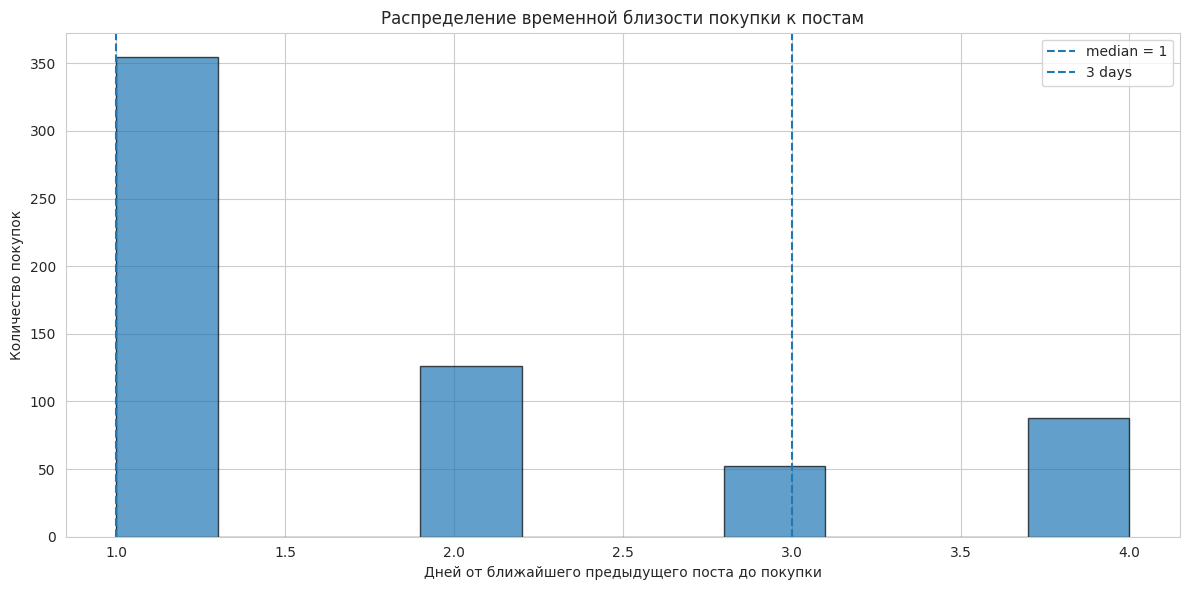


МЕТОД 2: KS / NULL MODEL
Real delta:   mean=1.80, median=1
Random delta: mean=1.58, median=1

Simple random-date KS: D=0.1111, p=0.0009
Circular-shift permutation: D=0.1111, p=0.7373

Вывод: отличие от null-модели статистически не обнаружено


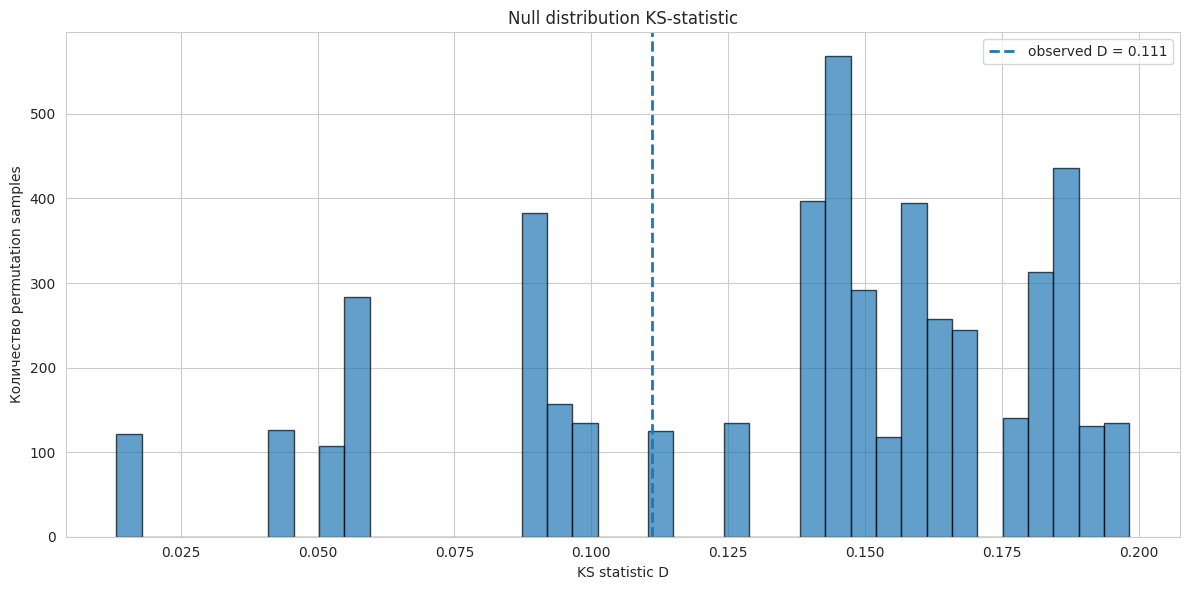


МЕТОД 3: EVENT STUDY
discount  : baseline=1.10, peak offset=14, peak relative revenue=2.21
urgency   : baseline=1.01, peak offset=8, peak relative revenue=2.04


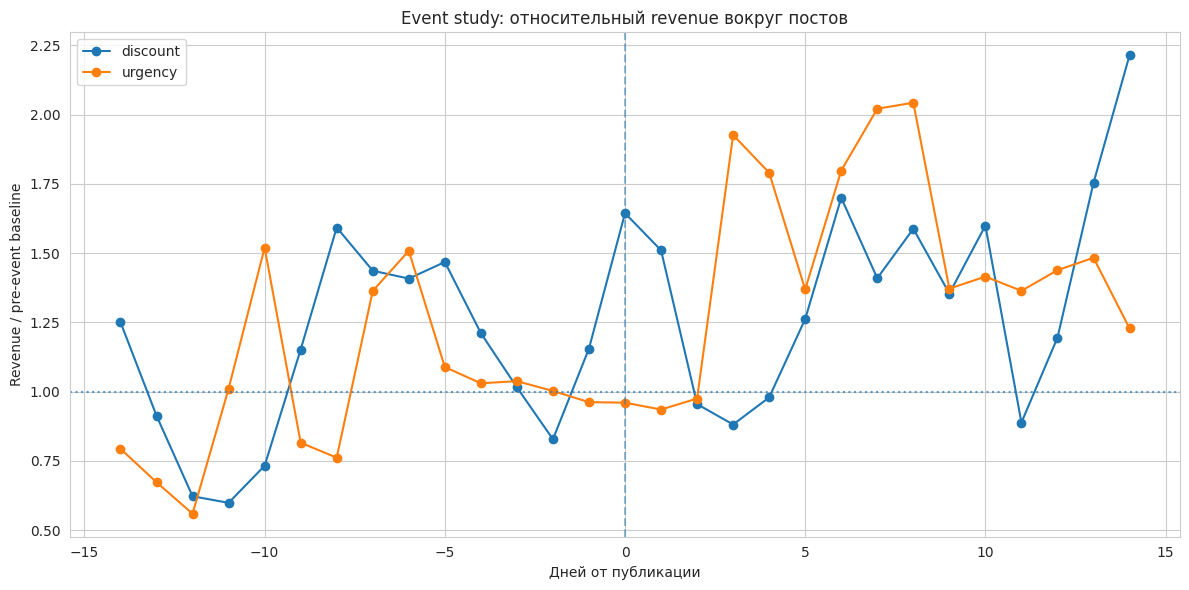


МЕТОД 4: SENSITIVITY ANALYSIS

Coverage и количество candidate touches:
 window coverage median_candidate_touches p90_candidate_touches
      1    56.5%                      2.0                   4.0
      3    84.9%                      3.0                   9.0
      5    98.9%                      5.0                  11.0
      7    98.9%                      6.0                  13.0
     10    98.9%                      8.0                  18.0
     14    98.9%                     10.0                  21.0
     21    98.9%                     16.0                  27.0
     30    98.9%                     28.0                  36.0


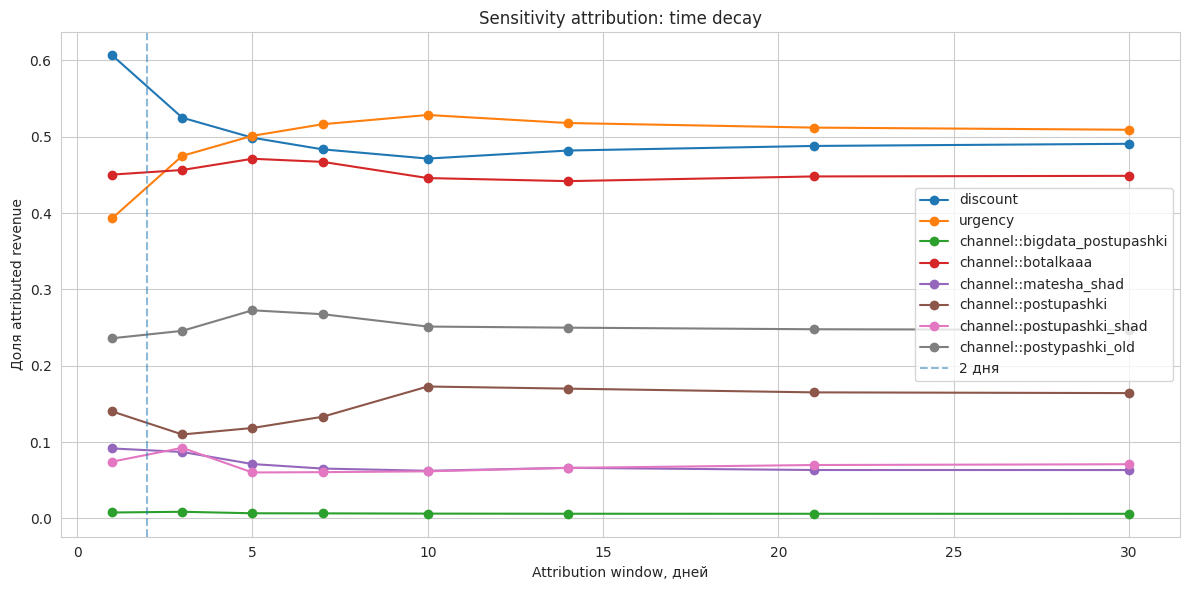

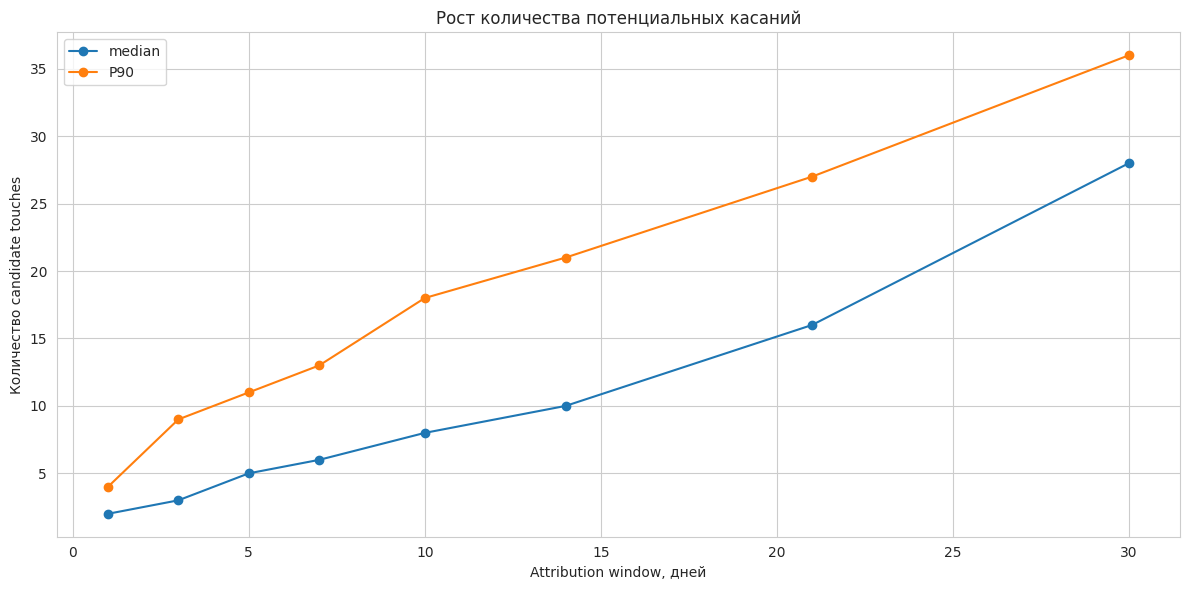


МЕТОД 5: EXPLORATORY REGRESSION
       feature          coef   pvalue  significant_05
 discount_lag7 -94525.022451 0.061792           False
         dow_6 139707.127632 0.066933           False
  urgency_lag7  79745.587678 0.103437           False
 discount_lag0  73009.556457 0.131451           False
         dow_3 -97215.063113 0.226321           False
         dow_1 -67789.700734 0.425013           False
         dow_4 -63800.443613 0.427777           False
 discount_lag3 -34491.991276 0.486727           False
 discount_lag1 -28448.864781 0.537508           False
         dow_2 -52566.916340 0.542893           False
discount_lag14  33079.487464 0.550546           False
  urgency_lag0 -20419.959921 0.646800           False
  urgency_lag1 -18132.236431 0.677902           False
 urgency_lag14  16232.063335 0.782049           False
         dow_5  15261.676189 0.853003           False
  urgency_lag3   3990.668140 0.926954           False

R² = 0.614
N = 38 days

ВАЖНО: регрессия использ

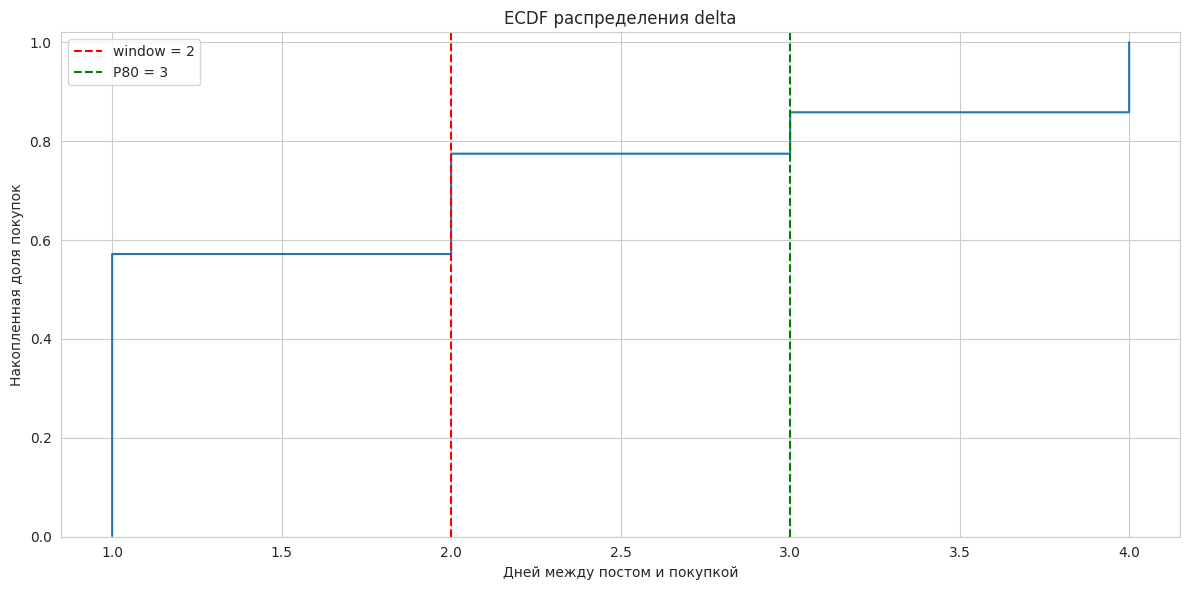

<Figure size 1200x600 with 0 Axes>

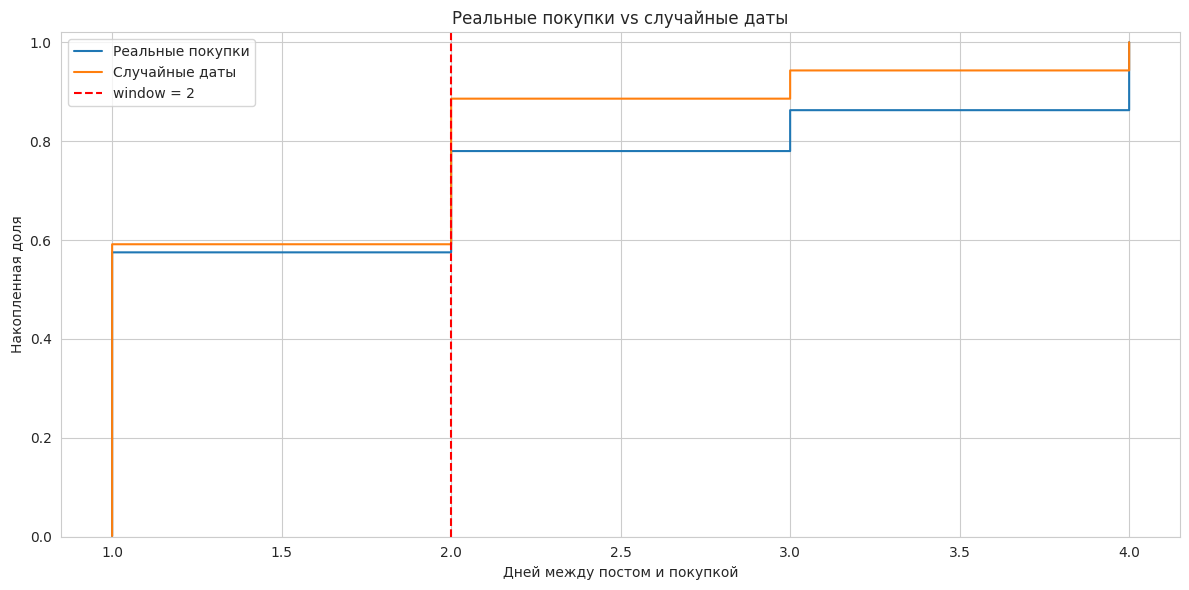

<Figure size 1200x600 with 0 Axes>

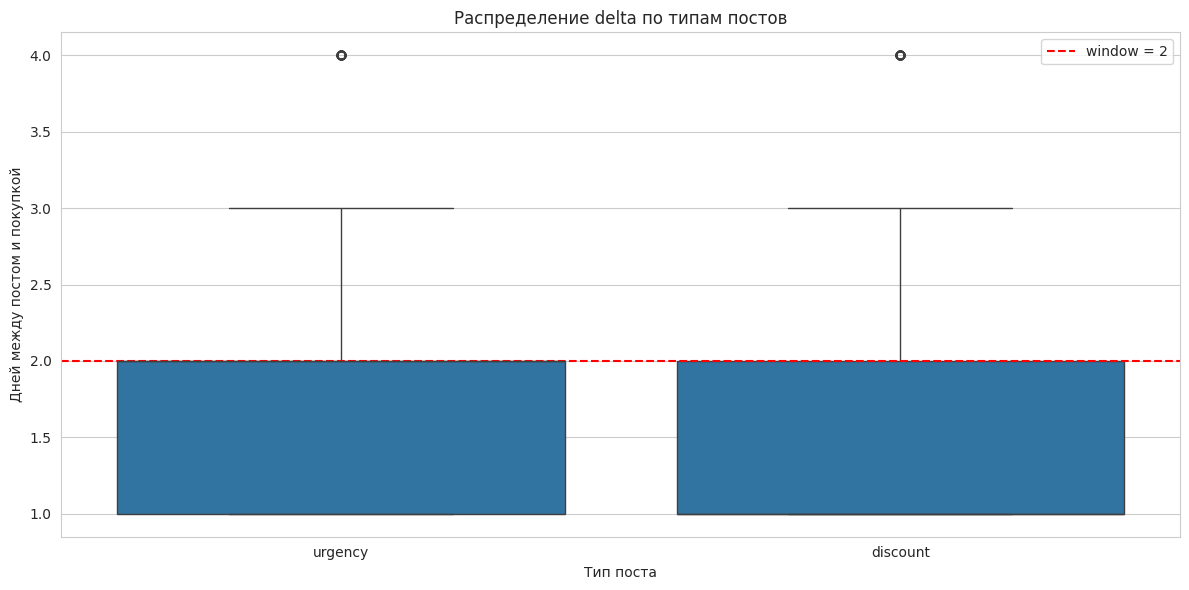

<Figure size 1200x600 with 0 Axes>

In [ ]:
main()

In [ ]:
n_users = 10_000
treatment_share = 0.9

# назначаем группы
group = np.random.choice(['treatment', 'control'],
                         size=n_users,
                         p=[treatment_share, 1 - treatment_share])

# baseline conversion (что было бы без рекламы)
baseline_cr = 0.03

# эффект рекламы (истинный, который мы хотим восстановить)
true_lift = 0.01   # +1 п.п.

# фактическая конверсия
cr = np.where(group == 'treatment', baseline_cr + true_lift, baseline_cr)
converted = np.random.binomial(1, cr)

# выручка
avg_order = 8000
revenue = converted * avg_order * np.random.uniform(0.8, 1.2, n_users)

df = pd.DataFrame({
    'user_id': range(n_users),
    'group': group,
    'converted': converted,
    'revenue': revenue,
})

1. A/B HOLDOUT EXPERIMENT
cr_treatment             : 0.0405
cr_control               : 0.0295
lift_cr_pp               : 1.0989
cr_ci_low                : -0.0190
cr_ci_high               : 2.2168
rpu_treatment            : 324.8153
rpu_control              : 236.6125
lift_rpu                 : 88.2029
rpu_ci_low               : -2.0269
rpu_ci_high              : 178.4326
incremental_revenue      : 792,414.5112
incremental_ci_low       : -18,209.7298
incremental_ci_high      : 1,603,038.7523

Истинный lift: 1.0 п.п.
Восстановленный: 1.10 п.п.
95% CI: [-0.02, 2.22]
Incremental revenue: 792,415 ₽
95% CI: [-18,210, 1,603,039] ₽

2. DIFFERENCE-IN-DIFFERENCES
DiD estimate: 15.38
Истинный эффект: 15.00

Средние по группам:
post                0           1
group                            
control    100.307040   99.943063
treatment   99.963091  114.982536

3. INTERRUPTED TIME SERIES
Level shift (post):    28068.11, p=0.0000
Trend change (t_post): -42.50, p=0.5356


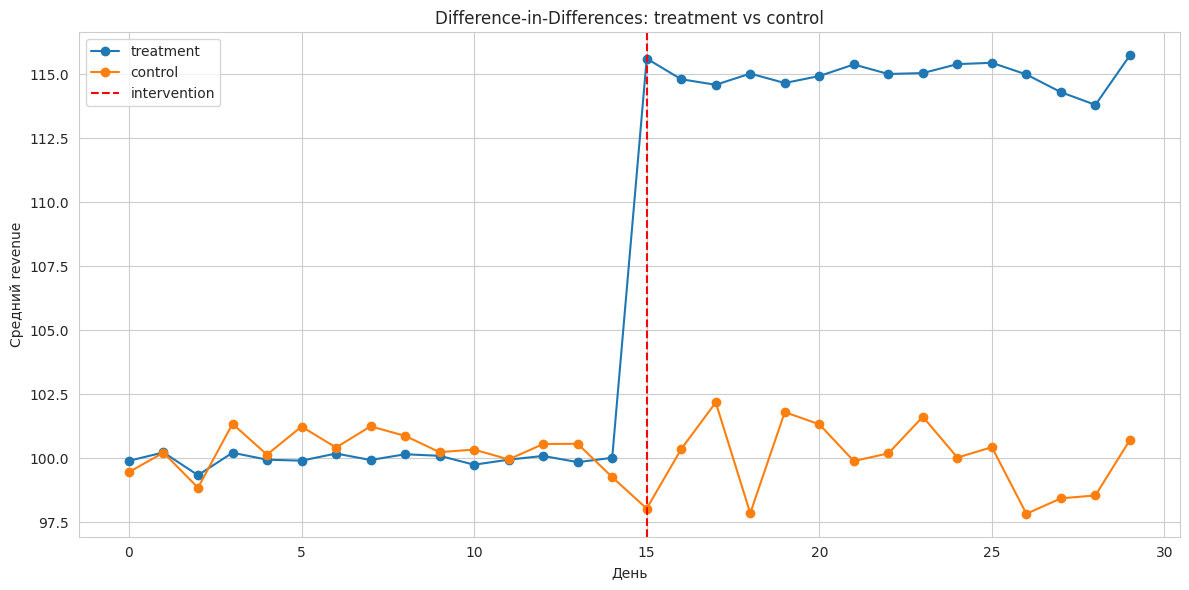


✓ Результаты сохранены в outputs/


In [ ]:
"""
Блок 7: Incrementality на mock-данных.
Демонстрация A/B holdout + DiD + ITS.
"""
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

# ============================================================
# 1. ГЕНЕРАЦИЯ MOCK-ЭКСПЕРИМЕНТА
# ============================================================

def generate_experiment(n_users=10_000, treat_share=0.9,
                         baseline_cr=0.03, true_lift=0.01, avg_order=8000):
    group = np.random.choice(['treatment', 'control'],
                             size=n_users, p=[treat_share, 1 - treat_share])
    cr = np.where(group == 'treatment', baseline_cr + true_lift, baseline_cr)
    converted = np.random.binomial(1, cr)
    revenue = converted * avg_order * np.random.uniform(0.8, 1.2, n_users)

    return pd.DataFrame({
        'user_id': range(n_users),
        'group': group,
        'converted': converted,
        'revenue': revenue,
    })


# ============================================================
# 2. INCREMENTAL REVENUE + CI
# ============================================================

def incremental_analysis(df, alpha=0.05):
    t = df[df['group'] == 'treatment']
    c = df[df['group'] == 'control']

    cr_t, cr_c = t['converted'].mean(), c['converted'].mean()
    rpu_t, rpu_c = t['revenue'].mean(), c['revenue'].mean()
    lift = rpu_t - rpu_c

    # CI для разницы пропорций
    x_t, n_t = t['converted'].sum(), len(t)
    x_c, n_c = c['converted'].sum(), len(c)
    p_t, p_c = x_t / n_t, x_c / n_c
    se_cr = np.sqrt(p_t * (1 - p_t) / n_t + p_c * (1 - p_c) / n_c)
    z = stats.norm.ppf(1 - alpha / 2)
    cr_ci = ((p_t - p_c) - z * se_cr, (p_t - p_c) + z * se_cr)

    # CI для разницы средних (revenue per user)
    se_rpu = np.sqrt(t['revenue'].var() / n_t + c['revenue'].var() / n_c)
    rpu_ci = (lift - z * se_rpu, lift + z * se_rpu)

    incremental = n_t * lift
    incremental_ci = (n_t * rpu_ci[0], n_t * rpu_ci[1])

    return {
        'cr_treatment': cr_t, 'cr_control': cr_c, 'lift_cr_pp': (cr_t - cr_c) * 100,
        'cr_ci_low': cr_ci[0] * 100, 'cr_ci_high': cr_ci[1] * 100,
        'rpu_treatment': rpu_t, 'rpu_control': rpu_c, 'lift_rpu': lift,
        'rpu_ci_low': rpu_ci[0], 'rpu_ci_high': rpu_ci[1],
        'incremental_revenue': incremental,
        'incremental_ci_low': incremental_ci[0],
        'incremental_ci_high': incremental_ci[1],
    }


# ============================================================
# 3. DIFFERENCE-IN-DIFFERENCES
# ============================================================

def generate_panel(n_users=2000, n_days=30, intervention_day=15,
                    baseline=100, lift=15, seed=42):
    np.random.seed(seed)
    users = []
    for u in range(n_users):
        group = np.random.choice(['treatment', 'control'], p=[0.9, 0.1])
        for d in range(n_days):
            post = 1 if d >= intervention_day else 0
            base = baseline + np.random.normal(0, 10)
            effect = lift if (group == 'treatment' and post) else 0
            revenue = max(0, base + effect + np.random.normal(0, 15))
            users.append({'user_id': u, 'day': d, 'group': group,
                          'post': post, 'revenue': revenue})

    return pd.DataFrame(users)


def did_analysis(df):
    means = df.groupby(['group', 'post'])['revenue'].mean().unstack()
    tau = (means.loc['treatment', 1] - means.loc['treatment', 0]) - \
          (means.loc['control', 1] - means.loc['control', 0])

    return tau, means


# ============================================================
# 4. INTERRUPTED TIME SERIES
# ============================================================

def its_analysis(daily, intervention_day):
    df = daily.copy()
    df['t'] = df['day']
    df['post'] = (df['day'] >= intervention_day).astype(int)
    df['t_post'] = df['t'] * df['post']
    X = sm.add_constant(df[['t', 'post', 't_post']])
    model = sm.OLS(df['revenue'], X).fit()

    return model


# ============================================================
# 5. MAIN
# ============================================================

# --- A/B holdout ---
print('=' * 60)
print('1. A/B HOLDOUT EXPERIMENT')
print('=' * 60)
exp = generate_experiment(true_lift=0.01)
result = incremental_analysis(exp)

for k, v in result.items():
    print(f'{k:25s}: {v:,.4f}')

print(f'\nИстинный lift: 1.0 п.п.')
print(f'Восстановленный: {result["lift_cr_pp"]:.2f} п.п.')
print(f'95% CI: [{result["cr_ci_low"]:.2f}, {result["cr_ci_high"]:.2f}]')
print(f'Incremental revenue: {result["incremental_revenue"]:,.0f} ₽')
print(f'95% CI: [{result["incremental_ci_low"]:,.0f}, '
        f'{result["incremental_ci_high"]:,.0f}] ₽')

# --- DiD ---
print('\n' + '=' * 60)
print('2. DIFFERENCE-IN-DIFFERENCES')
print('=' * 60)
panel = generate_panel()
tau, means = did_analysis(panel)
print(f'DiD estimate: {tau:.2f}')
print(f'Истинный эффект: {15:.2f}')
print('\nСредние по группам:')
print(means)

# --- ITS ---
print('\n' + '=' * 60)
print('3. INTERRUPTED TIME SERIES')
print('=' * 60)
daily = panel.groupby('day')['revenue'].sum().reset_index()
model = its_analysis(daily, intervention_day=15)
print(f'Level shift (post):    {model.params["post"]:.2f}, '
        f'p={model.pvalues["post"]:.4f}')
print(f'Trend change (t_post): {model.params["t_post"]:.2f}, '
        f'p={model.pvalues["t_post"]:.4f}')

# --- График DiD ---
fig, ax = plt.subplots(figsize=(12, 6))

for g in ['treatment', 'control']:
    sub = panel[panel['group'] == g].groupby('day')['revenue'].mean()
    ax.plot(sub.index, sub.values, marker='o', label=g)
ax.axvline(15, color='red', linestyle='--', label='intervention')
ax.set_xlabel('День')
ax.set_ylabel('Средний revenue')
ax.set_title('Difference-in-Differences: treatment vs control')
ax.legend()

plt.tight_layout()
plt.savefig(OUT / 'did_plot.png', dpi=120)
plt.show()
print('\n✓ Результаты сохранены в outputs/')